In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 6

## Tensor FLow
- Wines dataset
<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

## Import Statements

In [2]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path         # Import Path for file system path operations and management
import numpy as np               # Import NumPy for numerical computations and array operations
import pandas as pd              # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns            # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             f1_score)                 # Import function to calculate various metric

import tensorflow as tf

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

2025-11-13 11:13:04.227502: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# ###------------------
# ### Global Parameters
# ###------------------

# Directories
#inpDir = '../../input' 
inpDir = Path('..') / '..' / 'input'
# outDir = '../output'
outDir = Path('..') / 'output'


RANDOM_STATE = 24 
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(RANDOM_STATE)

TEST_SIZE  = 0.2 # Size of test data
EPOCHS = 100
ALPHA = 0.001

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [4]:
physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices)> 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [5]:
data_df = pd.read_csv('../../input/machine_learning/wine.csv', header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [7]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [8]:
for col in data_df.columns:
    print (f'Col: {col} - {data_df[col].unique()}')

Col: 0 - [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 13.29
 13.72 12.37 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 11.87 12.07 12.43 11.79
 12.04 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08
 12.79 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45
 12.82 13.4  12.2  14.16 13.27 14.13]
Col: 1 - [1.71 1.78 2.36 1.95 2.59 1.76 1.87 2.15 1.64 1.35 2.16 1.48 1.73 1.81
 1.92 1.57 1.59 3.1  1.63 3.8  1.86 1.6  2.05 1.77 1.72 1.9  1.68 1.5
 1.66 1.83 1.53 1.8  1.65 3.99 3.84 1.89 3.98 4.04 3.59 2.02 1.75 1.67
 1.

In [9]:
data_df.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

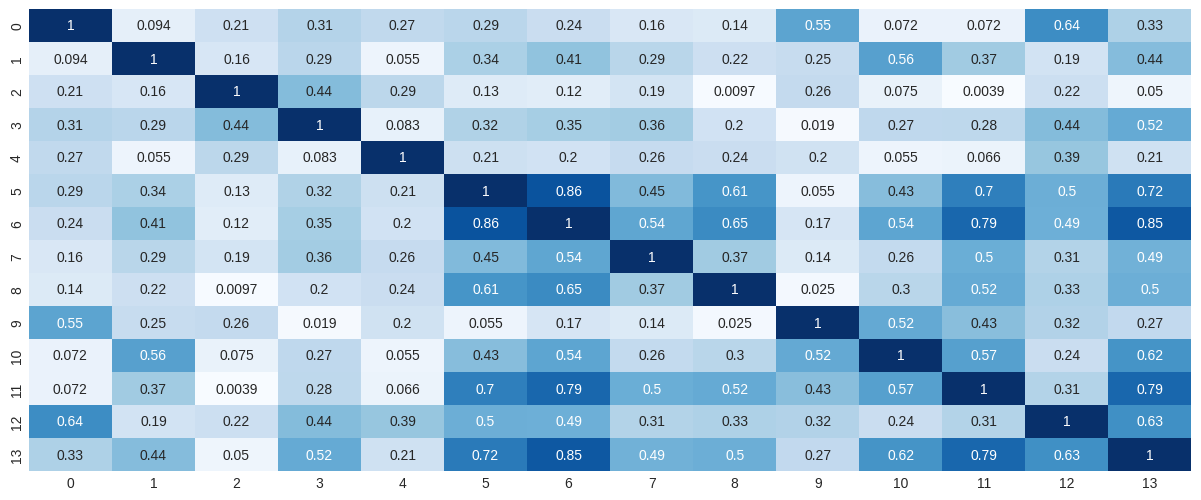

In [10]:
fig, ax = plt.subplots()
sns.heatmap(data_df.corr().abs(), 
            ax=ax, 
            cmap='Blues', 
            annot=True, 
            fmt='.2g',
            cbar=False
            );

In [11]:
labels = data_df[data_df.columns[-1]]
features_df = data_df.drop(data_df.columns[-1], axis=1)
features_df.shape, labels.shape

((178, 13), (178,))

In [12]:
X_train, X_test, y_train, y_test = train_test_split(features_df, labels, 
                                                    stratify=labels,
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [13]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.preprocessing import LabelEncoder # should be with imports

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Define model

In [15]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3)
])

I0000 00:00:1763012586.852183   31632 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [16]:
### functional API

# inputs = tf.keras.Input(shape=(X_train.shape[1],))
# x = tf.keras.layers.Dense(8, activation='relu')(inputs)
# outputs = tf.keras.layers.Dense(3)(x)
# model1 = tf.keras.Model(inputs=inputs, outputs=outputs)

In [17]:
X_train[:1].shape

(1, 13)

In [18]:
predictions = model(X_train[:1]).numpy()
predictions.sum()

np.float32(0.032134116)

In [19]:
tf.nn.softmax(predictions).numpy().sum()

np.float32(1.0)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [22]:
y_train[:1].shape, predictions.shape

((1,), (1, 3))

In [23]:
loss_fn(y_train[:1], predictions)

<tf.Tensor: shape=(), dtype=float32, numpy=1.0685616731643677>

In [24]:
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [25]:
model.compile(optimizer= optimizer,
              loss=loss_fn, metrics= ['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, 
                    validation_data=[X_test, y_test], 
                    epochs=EPOCHS)

Epoch 1/100


2025-11-13 11:13:08.101208: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ade9400a730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-13 11:13:08.101240: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-11-13 11:13:08.114036: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-13 11:13:08.178882: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3750 - loss: 1.3185

I0000 00:00:1763012588.868031   31713 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.3169 - loss: 1.5065 - val_accuracy: 0.2222 - val_loss: 1.3691
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3380 - loss: 1.4661 - val_accuracy: 0.2500 - val_loss: 1.3354
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3662 - loss: 1.4275 - val_accuracy: 0.3056 - val_loss: 1.3029
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3732 - loss: 1.3905 - val_accuracy: 0.3889 - val_loss: 1.2717
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3873 - loss: 1.3550 - val_accuracy: 0.3889 - val_loss: 1.2417
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4155 - loss: 1.3209 - val_accuracy: 0.4167 - val_loss: 1.2130
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4225 - loss: 1.2881 - val_accuracy: 0.4167 - val_loss: 1.1860
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4366 - loss: 1.2566 - val_accuracy: 0.4444 - val_loss: 1.1602
Epo

In [27]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.1174


[0.11743125319480896, 1.0]

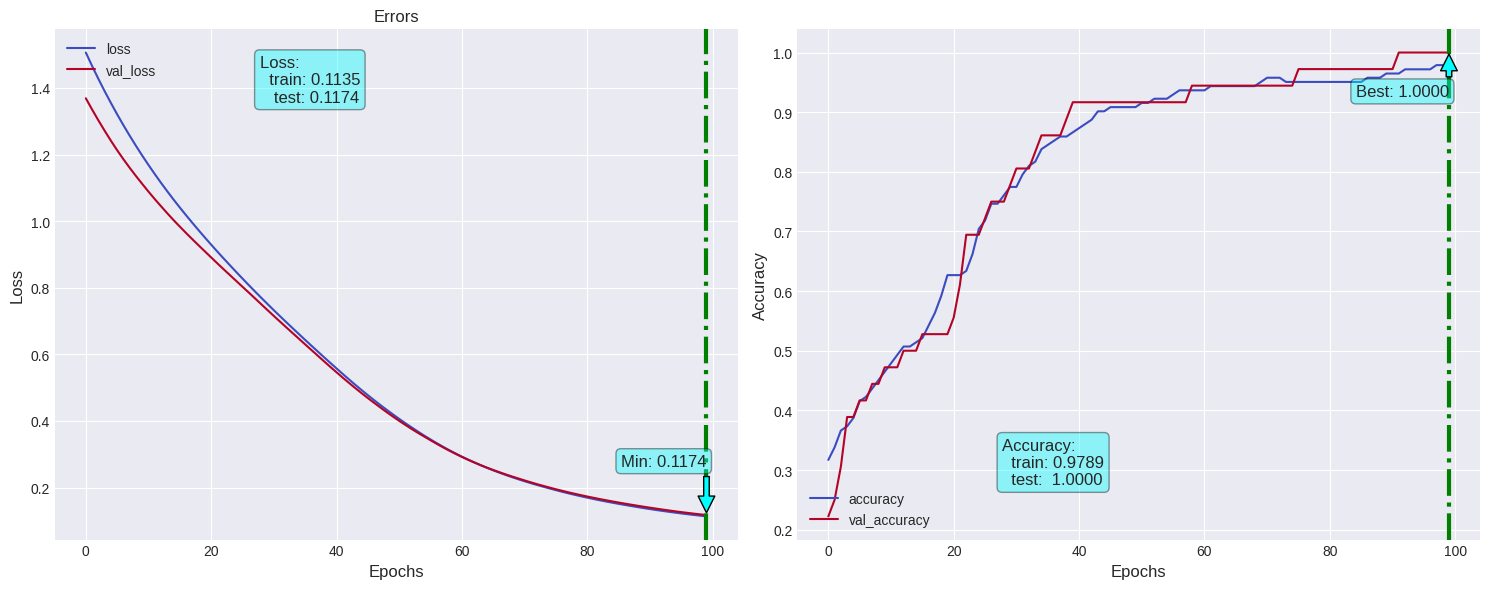

In [28]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [32]:
class_names = {}
for i, cl in enumerate(le.classes_):
    class_names[i] = cl

class_names

{0: np.int64(1), 1: np.int64(2), 2: np.int64(3)}

### Predictions

In [34]:
prob_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])

In [37]:
y_pred = prob_model(X_train).numpy()
print (f'Accuracy: {accuracy_score(y_train, y_pred.argmax(axis=1)):.4f}')
print (classification_report(y_train, y_pred.argmax(axis=1)))

Accuracy: 0.9789
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.98      0.96      0.97        57
           2       0.97      1.00      0.99        38

    accuracy                           0.98       142
   macro avg       0.98      0.98      0.98       142
weighted avg       0.98      0.98      0.98       142



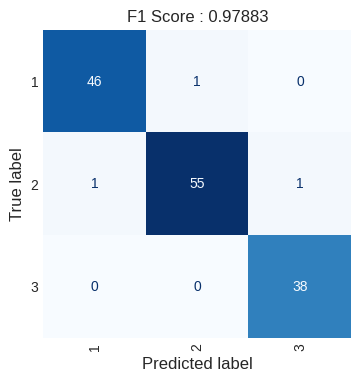

In [38]:
fn_plot_confusion_matrix(y_train, y_pred.argmax(axis=1), class_names)

Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



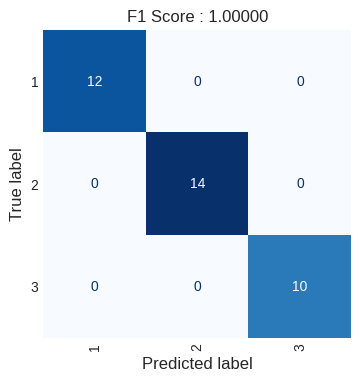

In [39]:
y_pred = prob_model(X_test).numpy()
print (f'Accuracy: {accuracy_score(y_test, y_pred.argmax(axis=1)):.4f}')
print (classification_report(y_test, y_pred.argmax(axis=1)))
fn_plot_confusion_matrix(y_test, y_pred.argmax(axis=1), class_names)